# Inference Configuration
Specify
- path

In [3]:
path = "../../output/protenn2/v5"


In [4]:
import json
import os.path
import pickle

import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.protenn2.utils import get_train_val_test_paths, get_device

# get file paths

log_path = os.path.join(path, "log")

label_encoder_path = os.path.join(path, "label_encoder.pkl")
model_path = os.path.join(path, "best_model.pt")
with open(os.path.join(path, "params.json"), "r") as f:
    params = json.load(f)
if "input_folder" not in params:
    raise ValueError("input_folder must be specified")
dataset_path = os.path.join("../../", params["input_folder"])
train_path, val_path, test_path = get_train_val_test_paths(dataset_path)


In [5]:
from src.protenn2.utils import calculate_max_protein_length
from src.protenn2.dataset import CathPredPerResidueDataset, create_protein_collate_fn
from src.protenn2.model import CathPredEnn2
from src.protenn2.analysis.cath_hierarchy_mapper import CATHHierarchyMapper

# Initialize objects

device = get_device()
with open(label_encoder_path, "rb") as f:
    label_encoder: LabelEncoder = pickle.load(f)
num_classes = len(label_encoder.classes_)
max_protein_length = calculate_max_protein_length(dataset_path)

model = CathPredEnn2(num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
test_dataset = CathPredPerResidueDataset(test_path, label_encoder=label_encoder,
                                         embedding_dir="../../data/embeddings/protein_embeddings_new")

collate_fn = create_protein_collate_fn(max_protein_length, test_dataset.padding_encoded_id)

test_dataloader = DataLoader(test_dataset, collate_fn=collate_fn)

mapper = CATHHierarchyMapper(label_encoder=label_encoder)

Using MPS (Apple Silicon GPU).
Max protein length: 599
Dataset initialized with 1317 unique proteins.


In [17]:
from src.protenn2.analysis.inference import run_inference

y_true_labels_list, y_pred_confidences_list, protein_chain_id_list = run_inference(model=model,
                                                                                   dataloader=test_dataloader,
                                                                                   padding_encoded_id=test_dataset.padding_encoded_id,
                                                                                   device=device,
                                                                                   return_protein_chain_id=True)

Running inference on 1317 proteins...


Inference Progress: 100%|██████████| 1317/1317 [00:04<00:00, 319.88it/s]


Inference complete. Processed 1317 proteins


# Analysis Configuration

In [7]:
from src.protenn2.utils import call_domains_list

bootstrap_samples = 1000
post_process_kwargs = {"reporting_threshold": 0.2, "region_min_length": 20, "gaussian_sigma": 1}
post_process_func = call_domains_list
metrics_to_compute = ("accuracy", "f1_score", "jaccard_score", "recall_score", "precision_score",
                      "segment_overlap_score")

# metrics_to_compute = ("segment_overlap_score")

In [8]:
from src.protenn2.analysis.metrics import calculate_metrics_for_cath_levels

all_results = calculate_metrics_for_cath_levels(y_true_labels_list=y_true_labels_list,
                                                y_pred_confidences_list=y_pred_confidences_list, mapper=mapper,
                                                bootstrap_samples=bootstrap_samples,
                                                post_process_func=post_process_func,
                                                post_process_kwargs=post_process_kwargs,
                                                metrics_to_compute=metrics_to_compute)

---- Computing Metrics for hierarchy: C
----- Accuracy Metrics -----


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:02<00:00, 384.88it/s]


{'mean': 0.7403300450807131, 'ci_lower': np.float64(0.7275101748438831), 'ci_upper': np.float64(0.7535130083025426), 'alpha': 0.05}
----- F1 Score Metrics -----


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:13<00:00, 74.12it/s]


{'mean': 0.7441503232176407, 'ci_lower': np.float64(0.7316071547178614), 'ci_upper': np.float64(0.7573192919824875), 'alpha': 0.05}
----- Jaccard Score Metrics -----


...

{'mean': 0.5253307655635641, 'ci_lower': np.float64(0.502426102624407), 'ci_upper': np.float64(0.548109480008659), 'alpha': 0.05}
----- Precision Score Metrics -----


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:41<00:00, 24.14it/s]


{'mean': 0.8647108379173903, 'ci_lower': np.float64(0.8681933959901632), 'ci_upper': np.float64(0.9019636315508046), 'alpha': 0.05}
----- Segment Overlap Score Metrics -----


Bootstrapping Progress: 100%|██████████| 1000/1000 [00:56<00:00, 17.62it/s]

{'mean': 51.82219507075253, 'ci_lower': np.float64(49.56103570975908), 'ci_upper': np.float64(54.227112250622824), 'alpha': 0.05}


# All results

In [9]:
all_results

{'raw_C': {'accuracy': {'mean': 0.7403300450807131,
   'ci_lower': np.float64(0.7275101748438831),
   'ci_upper': np.float64(0.7535130083025426),
   'alpha': 0.05},
  'f1_score': {'mean': 0.7441503232176407,
   'ci_lower': np.float64(0.7316071547178614),
   'ci_upper': np.float64(0.7573192919824875),
   'alpha': 0.05},
  'jaccard_score': {'mean': np.float64(0.6419132528111606),
   'ci_lower': np.float64(0.6233962666428363),
   'ci_upper': np.float64(0.6601067050887938),
   'alpha': 0.05},
  'recall_score': {'mean': 0.7424347555190529,
   'ci_lower': np.float64(0.7261152452099787),
   'ci_upper': np.float64(0.7588202688122467),
   'alpha': 0.05},
  'precision_score': {'mean': 0.8255914805236209,
   'ci_lower': np.float64(0.810777303724634),
   'ci_upper': np.float64(0.8406897899388556),
   'alpha': 0.05},
  'segment_overlap_score': {'mean': 53.5725462399978,
   'ci_lower': np.float64(51.36016168117169),
   'ci_upper': np.float64(55.665021316301996),
   'alpha': 0.05}},
 'post_C': {'accu

In [10]:
with open(os.path.join(path, "metrics_test.json"), "w") as f:
    json.dump(all_results, f)

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (0,).

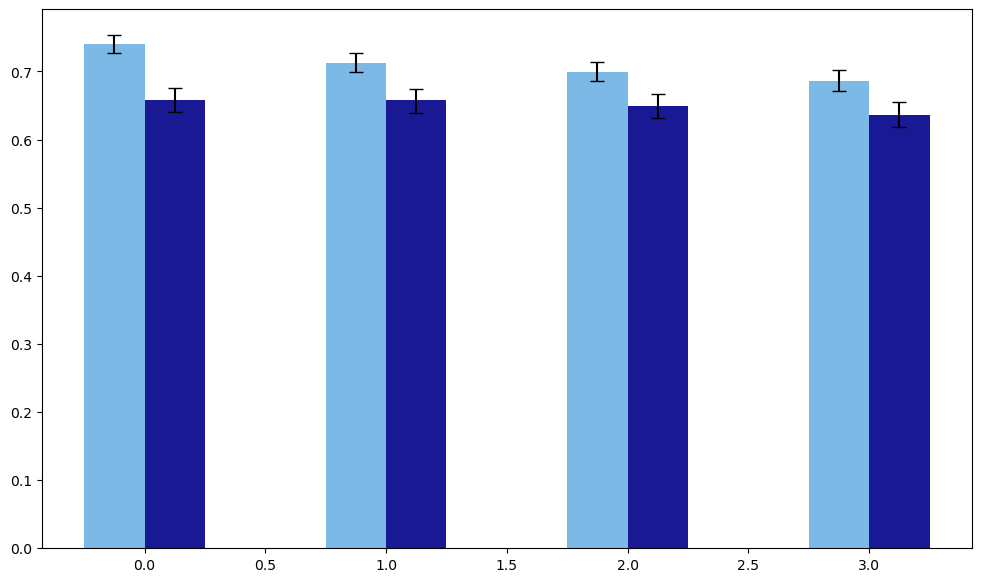

In [ ]:
plt = plot_metric_with_ci(all_results, "segment_overlap_score")
plt.show()

In [13]:
post_process_kwargs["no_domain_label_id"] = test_dataset.no_domain_encoded_id